In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
df = pd.read_csv('penguins data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Gender               334 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    float64
 16  C

In [17]:
print(df.isnull().sum())

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Gender                  10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64


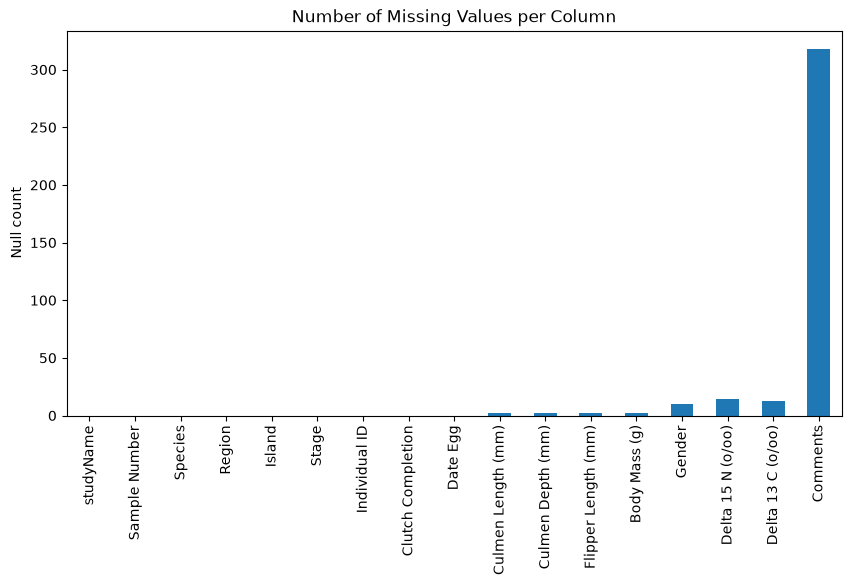

In [18]:
df.isnull().sum().plot(kind="bar", figsize=(10, 5))
plt.title("Number of Missing Values per Column")
plt.ylabel("Null count")
plt.show()

In [19]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

studyName              0
Sample Number          0
Species                0
Region                 0
Island                 0
Stage                  0
Individual ID          0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Gender                 0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
Comments               0
dtype: int64


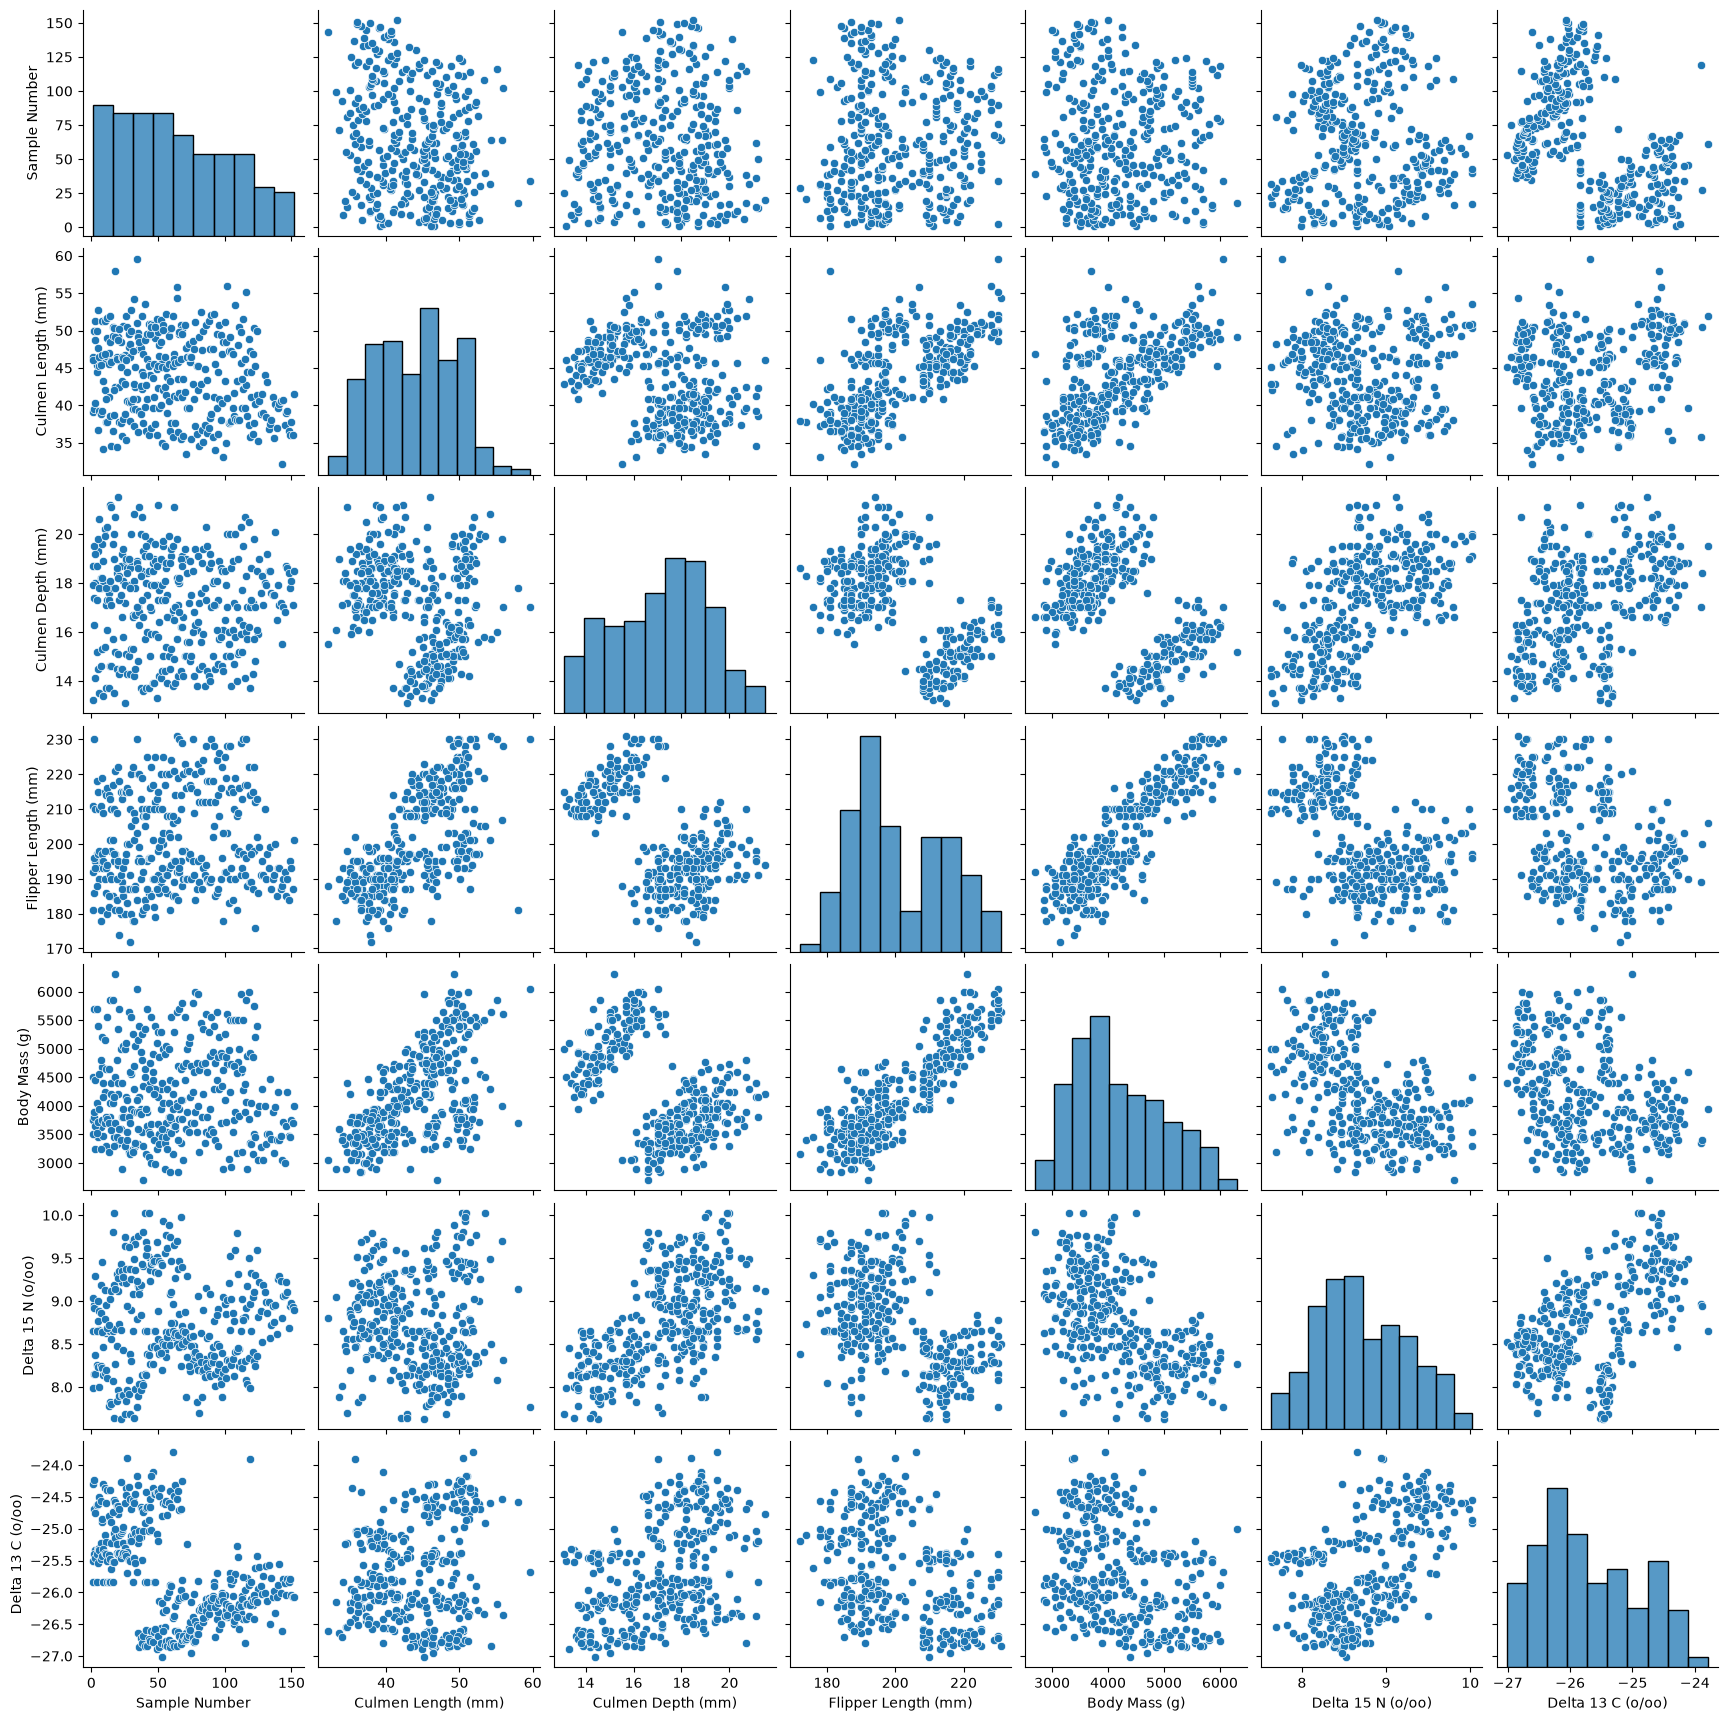

In [20]:
num_cols = df.select_dtypes(include="number").columns


sns.pairplot(df[num_cols])
plt.show()

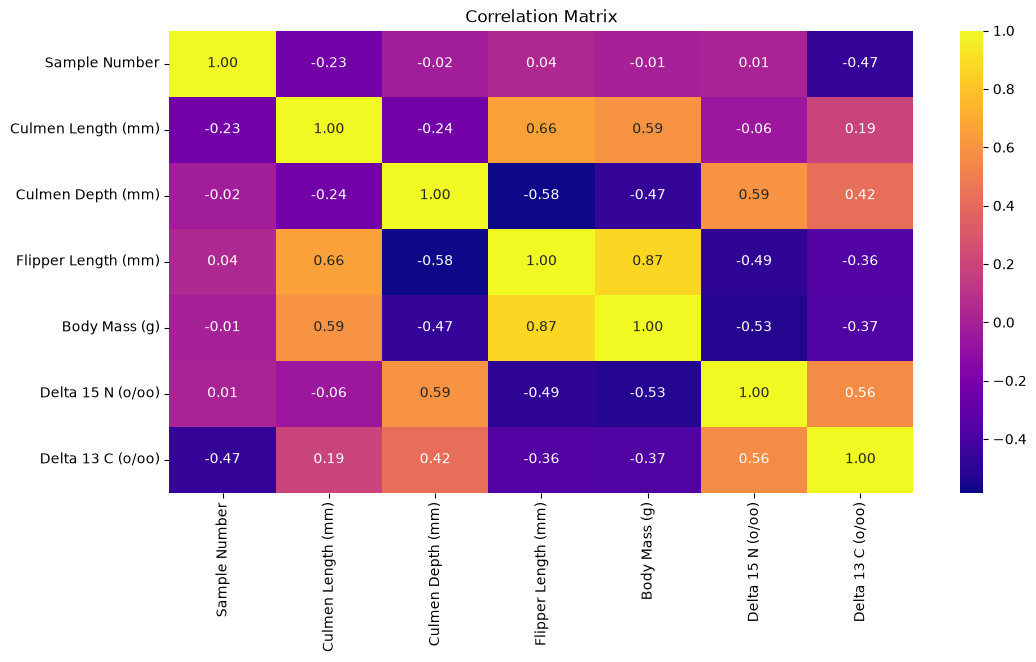

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='plasma', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Sample Number             Axes(0.125,0.653529;0.227941x0.226471)
Culmen Length (mm)     Axes(0.398529,0.653529;0.227941x0.226471)
Culmen Depth (mm)      Axes(0.672059,0.653529;0.227941x0.226471)
Flipper Length (mm)       Axes(0.125,0.381765;0.227941x0.226471)
Body Mass (g)          Axes(0.398529,0.381765;0.227941x0.226471)
Delta 15 N (o/oo)      Axes(0.672059,0.381765;0.227941x0.226471)
Delta 13 C (o/oo)             Axes(0.125,0.11;0.227941x0.226471)
dtype: object

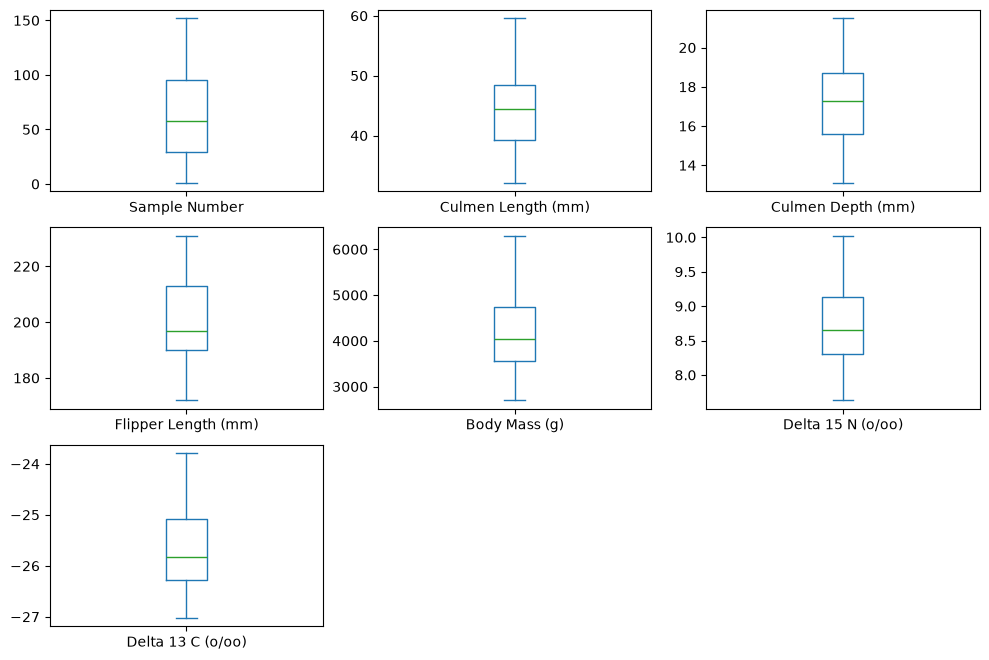

In [22]:
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(12, 8))

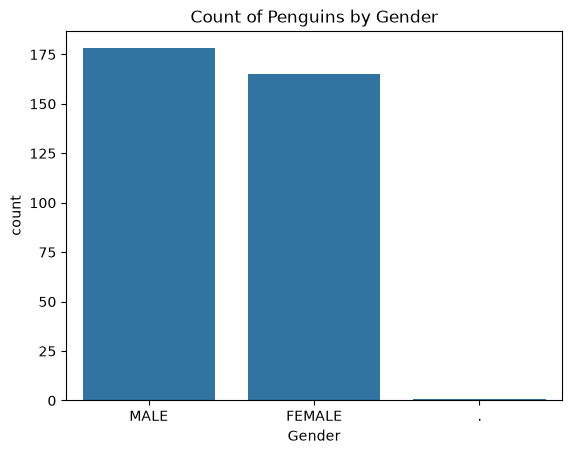

In [23]:
sns.countplot(x='Gender', data=df)
plt.title("Count of Penguins by Gender")
plt.show()